# Model Training - Keypoint Detection

**Team Member:** Annalena Salchegger

This notebook trains a keypoint detection model to predict head and tail positions for animal orientation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from pathlib import Path
import random
from tqdm.notebook import tqdm
import torchvision
import torchvision.transforms


### Deleting old model


In [ ]:
import os
old_model = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model.pth')
if old_model.exists():
    os.remove(old_model)
    print("Deleted old model weights")

Deleted old model weights


## Configuration

In [ ]:
DATA_DIR     = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
PROCESSED_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed')
LABELS_DIR   = PROCESSED_DIR / 'labels_keypoints'

TRAIN_IMG    = DATA_DIR / 'images' / 'train'
VAL_IMG      = DATA_DIR / 'images' / 'val'
TRAIN_LABELS = LABELS_DIR / 'train'
VAL_LABELS   = LABELS_DIR / 'val'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

IMG_SIZE = 256
BATCH_SIZE = 8
NUM_EPOCHS = 50 # to get better results, increase to 30-50 epochs
LEARNING_RATE = 1e-4
NUM_KEYPOINTS = 2  # head and tail
WARMUP_EPOCHS  = 2       # epochs to train only the head before unfreezing backbone

Using device: cuda


## Dataset

In [ ]:
class KeypointDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform
        
        self.samples = []
        for label_file in sorted(self.label_dir.glob('*.txt')):
            img_file = self.img_dir / f"{label_file.stem}.jpg"
            if not img_file.exists():
                for split in ['train', 'val', 'test']:
                    candidate = self.img_dir.parent / split / f"{label_file.stem}.jpg"
                    if candidate.exists():
                        img_file = candidate
                        break
                else:
                    continue

            with open(label_file) as f:
                for i, line in enumerate(f):
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        self.samples.append((img_file, label_file, i))

        print(f"  Found {len(self.samples)} animal samples in {label_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_file, label_file, animal_idx = self.samples[idx]
        
        img = Image.open(img_file).convert('RGB')
        orig_w, orig_h = img.size
        
        keypoints = torch.zeros(4, dtype=torch.float32)
        with open(label_file) as f:
            for i, line in enumerate(f):
                if i == animal_idx:
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        # Crop around bbox with padding
                        cx, cy = float(parts[1]), float(parts[2])
                        bw, bh = float(parts[3]), float(parts[4])
                        pad = 2.0

                        x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
                        y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
                        x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
                        y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

                        min_crop_px = orig_w * 0.10
                        if (x2 - x1) < min_crop_px:
                            mid_x = (x1 + x2) / 2
                            x1 = max(0, mid_x - min_crop_px / 2)
                            x2 = min(orig_w, mid_x + min_crop_px / 2)

                        min_crop_py = orig_h * 0.10    
                        if (y2 - y1) < min_crop_py:
                            mid_y = (y1 + y2) / 2
                            y1 = max(0, mid_y - min_crop_py / 2)
                            y2 = min(orig_h, mid_y + min_crop_py / 2)

                        crop_w = x2 - x1
                        crop_h = y2 - y1

                        img = img.crop((x1, y1, x2, y2))

                        head_x = max(0.0, min(1.0, (float(parts[5]) * orig_w - x1) / crop_w))
                        head_y = max(0.0, min(1.0, (float(parts[6]) * orig_h - y1) / crop_h))
                        tail_x = max(0.0, min(1.0, (float(parts[8]) * orig_w - x1) / crop_w))
                        tail_y = max(0.0, min(1.0, (float(parts[9]) * orig_h - y1) / crop_h))
                        
                        keypoints = torch.tensor(
                            [head_x, head_y, tail_x, tail_y],
                            dtype=torch.float32
                        )
                    break
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        
        return img, keypoints

In [ ]:
class KeypointDatasetWithFlip(KeypointDataset):
    def __getitem__(self, idx):
        img, keypoints = super().__getitem__(idx)
        if torch.rand(1) < 0.5:
            img = transforms.functional.hflip(img)
            keypoints[0] = 1 - keypoints[0]  # head_x
            keypoints[2] = 1 - keypoints[2]  # tail_x
        if torch.rand(1) < 0.5:
            img = transforms.functional.vflip(img)
            keypoints[1] = 1 - keypoints[1]  # head_y
            keypoints[3] = 1 - keypoints[3]  # tail_y
        return img, keypoints

In [6]:
# Data augmentation for limited real data
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

## Load datasets

train_dataset = KeypointDatasetWithFlip(TRAIN_IMG, TRAIN_LABELS, transform=train_transform)
val_dataset   = KeypointDataset(VAL_IMG,   VAL_LABELS,   transform=val_transform)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Warn if suspiciously empty
if len(train_dataset) == 0:
    raise RuntimeError("No training samples found! Check TRAIN_IMG and TRAIN_LABELS paths.")
if len(val_dataset) == 0:
    raise RuntimeError("No validation samples found! Check VAL_IMG and VAL_LABELS paths.")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

  Found 359 animal samples in /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/train
  Found 80 animal samples in /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val
Training samples:   359
Validation samples: 80


In [7]:
## Sanity check before training

print("=== Path check ===")
print(f"TRAIN_IMG exists:    {TRAIN_IMG.exists()}  ({TRAIN_IMG})")
print(f"VAL_IMG exists:      {VAL_IMG.exists()}  ({VAL_IMG})")
print(f"TRAIN_LABELS exists: {TRAIN_LABELS.exists()}  ({TRAIN_LABELS})")
print(f"VAL_LABELS exists:   {VAL_LABELS.exists()}  ({VAL_LABELS})")

print("\n=== Sample batch check ===")
imgs, kps = next(iter(train_loader))
print(f"Image batch shape:    {imgs.shape}")
print(f"Keypoints batch shape:{kps.shape}")
print(f"Keypoints sample:     {kps[0]}")
print(f"All zeros in batch?   {(kps == 0).all().item()}  <- should be False")

=== Path check ===
TRAIN_IMG exists:    True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/train)
VAL_IMG exists:      True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/val)
TRAIN_LABELS exists: True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/train)
VAL_LABELS exists:   True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val)

=== Sample batch check ===
Image batch shape:    torch.Size([8, 3, 256, 256])
Keypoints batch shape:torch.Size([8, 4])
Keypoints sample:     tensor([0.5260, 0.6086, 0.4865, 0.4747])
All zeros in batch?   False  <- should be False


## Model

In [8]:
class KeypointModel(nn.Module):
    def __init__(self, num_keypoints=2):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_keypoints * 2)
        )

    def forward(self, x):
        return torch.sigmoid(self.backbone(x))

model = KeypointModel(NUM_KEYPOINTS).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,001,380


## Training

In [15]:
#def keypoint_loss(outputs, targets):
    # Use sigmoid instead of clamp so gradients always flow
#    coord_loss  = nn.functional.mse_loss(outputs, targets)
#    pred_vec    = outputs[:, :2] - outputs[:, 2:]
#    true_vec    = targets[:, :2] - targets[:, 2:]
#    cos_sim     = nn.functional.cosine_similarity(pred_vec, true_vec, dim=1)
#    orient_loss = (1 - cos_sim).mean()
#    return coord_loss + 0.5 * orient_loss

def keypoint_loss(outputs, targets):
    coord_loss  = nn.functional.mse_loss(outputs, targets)
    pred_vec    = outputs[:, :2] - outputs[:, 2:]
    true_vec    = targets[:, :2] - targets[:, 2:]
    cos_sim     = nn.functional.cosine_similarity(pred_vec, true_vec, dim=1)
    orient_loss = (1 - cos_sim).mean()
    return coord_loss + 0.01 * orient_loss

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10)

# freeze backbone for warmup epochs so the new head stabilises first
print(f"Freezing backbone for first {WARMUP_EPOCHS} warmup epochs...")
for param in model.backbone.parameters():
    param.requires_grad = False
# Keep the new head trainable
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

Freezing backbone for first 2 warmup epochs...


In [16]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for imgs, keypoints in loader:
        imgs = imgs.to(device)
        keypoints = keypoints.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)           
        loss = keypoint_loss(outputs, keypoints)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def validate(model, loader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for imgs, keypoints in loader:
            imgs = imgs.to(device)
            keypoints = keypoints.to(device)
            outputs = model(imgs)       # ← no clamp needed, no backward pass
            loss = keypoint_loss(outputs, keypoints)
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [17]:
print(val_dataset.samples[0])  # should show 3 values: (img, label, animal_idx)

(PosixPath('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/train/115_5727.jpg'), PosixPath('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val/115_5727.txt'), 0)


In [18]:
# Check what loss a dumb baseline gets
dummy_preds = torch.full((len(val_dataset), 4), 0.5)  # predict center for everything
dummy_targets = torch.stack([val_dataset[i][1] for i in range(len(val_dataset))])

baseline_loss = nn.functional.mse_loss(dummy_preds, dummy_targets)
print(f"Baseline loss (always predict 0.5): {baseline_loss:.4f}")

# Check target distribution
print(f"\nTarget statistics:")
print(f"  Mean: {dummy_targets.mean(dim=0)}")
print(f"  Std:  {dummy_targets.std(dim=0)}")
print(f"  Min:  {dummy_targets.min(dim=0).values}")
print(f"  Max:  {dummy_targets.max(dim=0).values}")

# Check a few actual samples
print(f"\nSample keypoints from val set:")
for i in range(5):
    _, kp = val_dataset[i]
    print(f"  {kp.numpy()}")

Baseline loss (always predict 0.5): 0.0246

Target statistics:
  Mean: tensor([0.4838, 0.4915, 0.5108, 0.4855])
  Std:  tensor([0.0914, 0.2012, 0.0955, 0.2027])
  Min:  tensor([0.1966, 0.0000, 0.3314, 0.0000])
  Max:  tensor([0.9688, 1.0000, 0.9585, 1.0000])

Sample keypoints from val set:
  [0.44401747 0.46100596 0.58196414 0.48004928]
  [0.40278035 0.5233043  0.5147884  0.53758657]
  [0.48793173 0.5306385  0.5131845  0.46995658]
  [0.41184223 0.56667143 0.5591439  0.46822855]
  [0.5044168  0.534515   0.5044168  0.43771288]


In [19]:
# Look at the raw label file content
label_file = val_dataset.samples[0][1]
print(f"File: {label_file}")
print(f"\nRaw content:")
with open(label_file) as f:
    for line in f:
        print(f"  {line.strip()}")
        parts = line.strip().split()
        if len(parts) >= 11:
            print(f"    class={parts[0]}")
            print(f"    bbox:  cx={parts[1]}, cy={parts[2]}, w={parts[3]}, h={parts[4]}")
            print(f"    head:  x={parts[5]}, y={parts[6]}, vis={parts[7]}")
            print(f"    tail:  x={parts[8]}, y={parts[9]}, vis={parts[10]}")

File: /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val/115_5727.txt

Raw content:
  28 0.34033203125 0.313232421875 0.0361328125 0.03271484375 0.330218 0.306854 1 0.355140 0.309969 1
    class=28
    bbox:  cx=0.34033203125, cy=0.313232421875, w=0.0361328125, h=0.03271484375
    head:  x=0.330218, y=0.306854, vis=1
    tail:  x=0.355140, y=0.309969, vis=1


In [20]:
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

MODEL_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(NUM_EPOCHS):

    # unfreeze backbone after warmup and lower LR
    if epoch == WARMUP_EPOCHS:
        print(f"\nEpoch {epoch+1}: Unfreezing backbone with lower LR...")
        for param in model.backbone.parameters():
            param.requires_grad = True
        for g in optimizer.param_groups:
            g['lr'] = LEARNING_RATE * 0.1

    train_loss = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = validate(model, val_loader, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_DIR / 'best_keypoint_model.pth')
        print(f"  -> Saved best model!")

Epoch 1/50 - Train Loss: 0.0329, Val Loss: 0.0346
  -> Saved best model!
Epoch 2/50 - Train Loss: 0.0314, Val Loss: 0.0359

Epoch 3: Unfreezing backbone with lower LR...
Epoch 3/50 - Train Loss: 0.0324, Val Loss: 0.0355
Epoch 4/50 - Train Loss: 0.0318, Val Loss: 0.0347
Epoch 5/50 - Train Loss: 0.0316, Val Loss: 0.0340
  -> Saved best model!
Epoch 6/50 - Train Loss: 0.0326, Val Loss: 0.0339
  -> Saved best model!
Epoch 7/50 - Train Loss: 0.0320, Val Loss: 0.0335
  -> Saved best model!
Epoch 8/50 - Train Loss: 0.0309, Val Loss: 0.0337
Epoch 9/50 - Train Loss: 0.0318, Val Loss: 0.0334
  -> Saved best model!
Epoch 10/50 - Train Loss: 0.0310, Val Loss: 0.0337
Epoch 11/50 - Train Loss: 0.0313, Val Loss: 0.0333
  -> Saved best model!
Epoch 12/50 - Train Loss: 0.0327, Val Loss: 0.0334
Epoch 13/50 - Train Loss: 0.0311, Val Loss: 0.0338
Epoch 14/50 - Train Loss: 0.0310, Val Loss: 0.0338
Epoch 15/50 - Train Loss: 0.0308, Val Loss: 0.0329
  -> Saved best model!
Epoch 16/50 - Train Loss: 0.0319, Va

## Training Curves

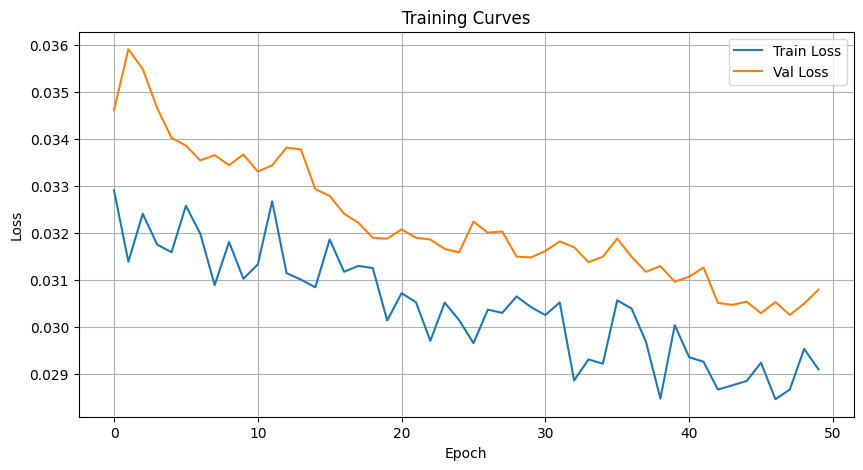

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.show()

## Save Model

In [24]:
import os
os.makedirs('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models', exist_ok=True)
torch.save(model.state_dict(), '/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/keypoint_model_final.pth')
print("Model saved!")

Model saved!
